In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 09

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196


# PROBLEM 1
## Coupled Oscillators

Two masses connected by three springs (wall–$m_1$–$m_2$–wall) obey:

$$
m_1\ddot{x}_1 = -(k_1+k_2)x_1 + k_2 x_2
$$
$$
m_2\ddot{x}_2 = k_2 x_1 - (k_2+k_3)x_2
$$

where $x_1, x_2$ are displacements from equilibrium, $k_1, k_3$ are the wall springs, and $k_2$ is the coupling spring between the masses.

### Normal Modes

For the symmetric case ($m_1=m_2=m$, $k_1=k_2=k_3=k$) the two normal-mode frequencies are:

$$
\omega_1 = \sqrt{\frac{k}{m}} \quad \text{(in-phase mode)}, \qquad \omega_2 = \sqrt{\frac{3k}{m}} \quad \text{(out-of-phase mode)}
$$

A general motion is a superposition of these two modes.

### Euler-Cromer Discretisation

Setting $v_i = \dot{x}_i$, the Euler-Cromer algorithm is:

$$
a_1^{(n)} = \frac{-(k_1+k_2)x_1^{(n)} + k_2 x_2^{(n)}}{m_1}, \qquad
a_2^{(n)} = \frac{k_2 x_1^{(n)} - (k_2+k_3)x_2^{(n)}}{m_2}
$$
$$
v_i^{(n+1)} = v_i^{(n)} + \Delta t\, a_i^{(n)}, \qquad
x_i^{(n+1)} = x_i^{(n)} + \Delta t\, v_i^{(n+1)}
$$

Initial conditions: $x_1(0)=1$, $x_2(0)=0$, $v_1(0)=v_2(0)=0$ (mass 1 displaced, mass 2 at rest).


## Euler-Cromer Solver


In [ ]:
def simulate(m1, m2, k1, k2, k3, t_max=50, dt=0.01):
    """Euler-Cromer solver for two coupled oscillators."""
    N = int(t_max / dt)
    t  = np.linspace(0, t_max, N)
    x1 = np.zeros(N);  x2 = np.zeros(N)
    v1 = np.zeros(N);  v2 = np.zeros(N)

    # Initial conditions: displace mass 1 only
    x1[0] = 1.0

    for n in range(N - 1):
        a1 = (-(k1 + k2)*x1[n] + k2*x2[n]) / m1
        a2 = ( k2*x1[n] - (k2 + k3)*x2[n]) / m2

        v1[n+1] = v1[n] + dt * a1   # update velocities first
        v2[n+1] = v2[n] + dt * a2

        x1[n+1] = x1[n] + dt * v1[n+1]  # then positions
        x2[n+1] = x2[n] + dt * v2[n+1]

    return t, x1, x2


---
## Part (a): Symmetric Case — $m_1=m_2=1$, $k_1=k_2=k_3=1$

With equal masses and equal spring constants the two normal-mode frequencies are $\omega_1 = 1$ rad/s and $\omega_2 = \sqrt{3}$ rad/s. Starting with only $x_1$ displaced, the motion is a superposition of both modes — energy transfers back and forth between the two masses in a regular pattern.


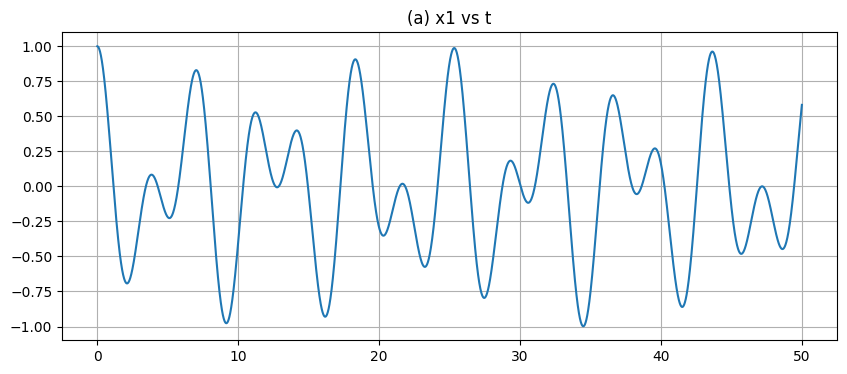

In [ ]:
t, x1, x2 = simulate(m1=1, m2=1, k1=1, k2=1, k3=1)

plt.figure(figsize=(10, 4))
plt.plot(t, x1, color='steelblue', linewidth=0.8)
plt.title('(a) $x_1$ vs $t$ — Symmetric Case ($m_1=m_2=1$, $k_1=k_2=k_3=1$)')
plt.xlabel('$t$');  plt.ylabel('$x_1(t)$')
plt.grid();  plt.tight_layout();  plt.show()


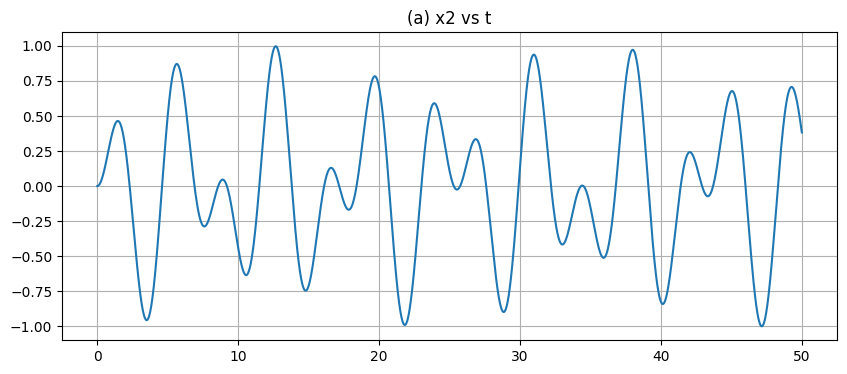

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, x2, color='crimson', linewidth=0.8)
plt.title('(a) $x_2$ vs $t$ — Symmetric Case ($m_1=m_2=1$, $k_1=k_2=k_3=1$)')
plt.xlabel('$t$');  plt.ylabel('$x_2(t)$')
plt.grid();  plt.tight_layout();  plt.show()


### Observations — Part (a)

The motion of each mass is a superposition of the two normal modes at frequencies $\omega_1 = 1$ and $\omega_2 = \sqrt{3}$ rad/s. Since $\omega_2/\omega_1 = \sqrt{3}$ is irrational, the motion is **quasi-periodic** — it never exactly repeats. Energy is exchanged between the two masses in an irregular but bounded pattern.

Both amplitudes remain close to 1 since there is no damping. The coupling spring ($k_2=1$) is strong enough to transfer energy efficiently between the masses within a few cycles.


---
## Part (b): Heavy Second Mass — $m_1=1$, $m_2=200$, $k_1=k_2=k_3=1$

Now $m_2$ is 200 times heavier than $m_1$. Physically, a very heavy mass responds very slowly to forces. The coupling spring $k_2$ exerts the same force on both masses, but the acceleration of $m_2$ is $a_2 = F/m_2$ — 200 times smaller. We expect $m_2$ to barely move while $m_1$ oscillates rapidly.


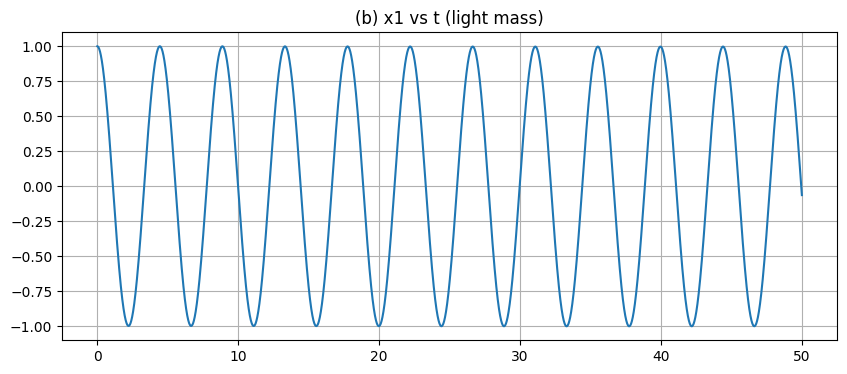

In [ ]:
t, x1, x2 = simulate(m1=1, m2=200, k1=1, k2=1, k3=1)

plt.figure(figsize=(10, 4))
plt.plot(t, x1, color='steelblue', linewidth=0.8)
plt.title('(b) $x_1$ vs $t$ — Light Mass ($m_1=1$, $m_2=200$)')
plt.xlabel('$t$');  plt.ylabel('$x_1(t)$')
plt.grid();  plt.tight_layout();  plt.show()


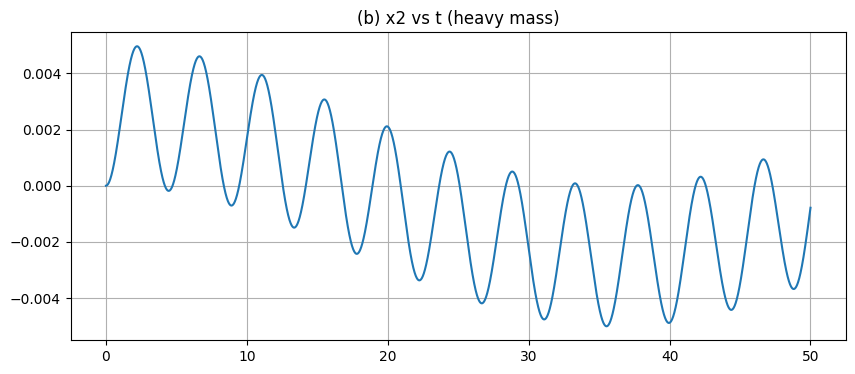

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, x2, color='crimson', linewidth=0.8)
plt.title('(b) $x_2$ vs $t$ — Heavy Mass ($m_1=1$, $m_2=200$)')
plt.xlabel('$t$');  plt.ylabel('$x_2(t)$')
plt.grid();  plt.tight_layout();  plt.show()


### Observations and Physical Interpretation — Part (b)

**$x_1$ (light mass, $m_1=1$):** Oscillates rapidly and with nearly full amplitude. The light mass sees the heavy mass as essentially a fixed wall — $m_2$ is so inertially large that it barely moves, so $m_1$ simply bounces between its own wall spring $k_1$ and the coupling spring $k_2$, both anchored at effectively fixed points. Its frequency is approximately:

$$
\omega_1 \approx \sqrt{\frac{k_1+k_2}{m_1}} = \sqrt{2} \text{ rad/s}
$$

**$x_2$ (heavy mass, $m_2=200$):** Moves with extremely small amplitude (orders of magnitude smaller than $x_1$). The force on $m_2$ from the coupling spring is $k_2 x_1 \sim 1$, giving acceleration $\sim 1/200 = 0.005$ — tiny. The heavy mass slowly drifts but scarcely oscillates on the timescale shown.

**General principle:** In the limit $m_2 \to \infty$, the two oscillators decouple completely — $m_1$ does not "know" $m_2$ is there, and $m_2$ does not respond to $m_1$ at all.


---
## Part (c): Weak Coupling — $m_1=m_2=1$, $k_1=k_3=1$, $k_2=0.1$

Now the coupling spring $k_2 = 0.1$ is much weaker than the wall springs $k_1=k_3=1$. The two normal-mode frequencies are:

$$
\omega_1 = \sqrt{\frac{k_1}{m}} = 1 \text{ rad/s}, \qquad
\omega_2 = \sqrt{\frac{k_1 + 2k_2}{m}} = \sqrt{1.2} \approx 1.095 \text{ rad/s}
$$

These frequencies are very close to each other. The general solution is a superposition of both modes, which can be written as:

$$
x_1(t) \propto \cos\!\left(\frac{\omega_2-\omega_1}{2}t\right)\cos\!\left(\frac{\omega_1+\omega_2}{2}t\right)
$$

This is a **fast oscillation** at the average frequency $\bar{\omega} \approx 1.048$ rad/s modulated by a **slow envelope** at the beat frequency:

$$
\omega_{\text{beat}} = \omega_2 - \omega_1 \approx 0.095 \text{ rad/s}, \qquad T_{\text{beat}} = \frac{2\pi}{\omega_{\text{beat}}} \approx 66 \text{ s}
$$

Energy oscillates slowly and completely between $m_1$ and $m_2$ with period $T_{\text{beat}}$. When $x_1$ has maximum amplitude, $x_2 \approx 0$, and vice versa.


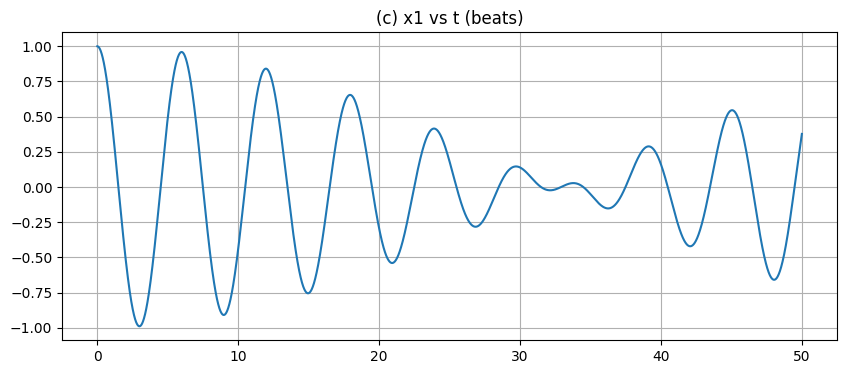

In [ ]:
t, x1, x2 = simulate(m1=1, m2=1, k1=1, k2=0.1, k3=1, t_max=150)

plt.figure(figsize=(10, 4))
plt.plot(t, x1, color='steelblue', linewidth=0.6)
plt.title('(c) $x_1$ vs $t$ — Weak Coupling / Beats ($k_2=0.1$)')
plt.xlabel('$t$');  plt.ylabel('$x_1(t)$')
plt.grid();  plt.tight_layout();  plt.show()


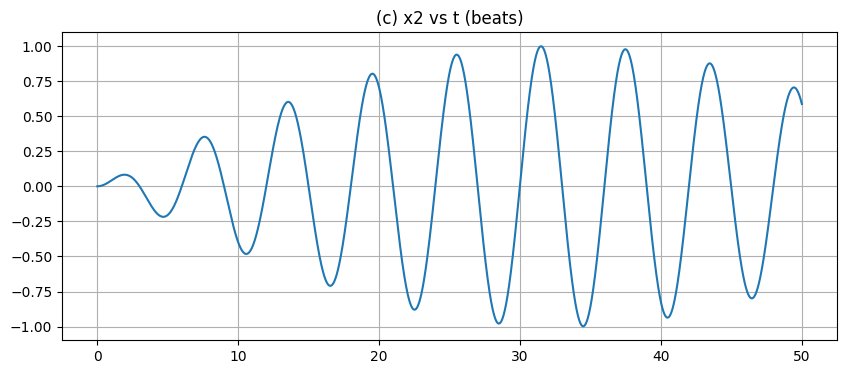

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t, x2, color='crimson', linewidth=0.6)
plt.title('(c) $x_2$ vs $t$ — Weak Coupling / Beats ($k_2=0.1$)')
plt.xlabel('$t$');  plt.ylabel('$x_2(t)$')
plt.grid();  plt.tight_layout();  plt.show()


### Observations — Part (c): Beats

The graphs clearly show the **beating phenomenon**: a rapid oscillation whose amplitude is slowly modulated. The key features are:

- **$x_1$**: Starts with full amplitude (~1), which slowly decreases to nearly zero, then grows back — this cycle repeats with period $T_{\text{beat}} \approx 66$ s.
- **$x_2$**: Starts near zero (undisturbed), gradually receives energy from $m_1$, reaches full amplitude when $x_1 \approx 0$, then returns energy back.

The two graphs are **$180°$ out of phase** in their envelopes — when one mass has maximum energy the other has minimum. This complete energy transfer is only possible because $m_1 = m_2$ and $k_1 = k_3$ (symmetric system); any asymmetry would prevent complete transfer.

**Physical analogy:** This is the mechanical analogue of quantum tunnelling or optical mode coupling — a classical demonstration of resonant energy exchange between two identical oscillators connected by a weak link.


---
## Conclusion

We numerically solved the coupled oscillator equations using the Euler-Cromer algorithm for three physically distinct parameter sets:

- **Part (a)** ($m_1=m_2=1$, $k_1=k_2=k_3=1$): Both masses oscillate with comparable amplitudes in a quasi-periodic pattern — superposition of two normal modes at $\omega_1=1$ and $\omega_2=\sqrt{3}$ rad/s.

- **Part (b)** ($m_1=1$, $m_2=200$): The heavy mass barely moves; the light mass oscillates independently at $\omega \approx \sqrt{2}$ rad/s as if the coupling were anchored to a fixed wall. The oscillators effectively decouple when there is a large mass mismatch.

- **Part (c)** ($k_2=0.1 \ll k_1=k_3=1$): Weak coupling produces two nearly degenerate normal modes. Their superposition gives beats: complete, periodic energy transfer between the masses at the slow beat frequency $\omega_{\text{beat}} = \omega_2 - \omega_1 \approx 0.095$ rad/s.
